In [1]:
import pandas as pd

df1 = pd.read_csv('2015-2025_california.csv')
df2 = pd.read_csv('2005-2015_california.csv')
df3 = pd.read_csv('1995-2005_california.csv')
# df4 = pd.read_csv('1986-1995_california.csv')

df = pd.concat([df1, df2, df3], ignore_index=True)

In [2]:
len(df)

45345

In [3]:
import pandas as pd
import numpy as np

# 1) Load and concatenate all catalogs
df1 = pd.read_csv('2015-2025_california.csv')
df2 = pd.read_csv('2005-2015_california.csv')
df3 = pd.read_csv('1995-2005_california.csv')
df4 = pd.read_csv('1986-1995_california.csv')

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# 2) Drop exact duplicates based on the unique USGS 'id' to fix overlapping years
df = df.drop_duplicates(subset=['id']).copy()

# 3) Datetime conversion + chronological sorting
df['time'] = pd.to_datetime(df['time'], errors='coerce', utc=True)
df = df.dropna(subset=['time']).sort_values('time').reset_index(drop=True)

# 4) Relaxed magType filter (Optional: if you want md included)
if 'magType' in df.columns:
    mag_type = df['magType'].astype('string').str.lower()
    # Keep ml, mw, and md (duration magnitude used in older catalogs)
    df = df[mag_type.isin(['ml', 'mw', 'md'])].copy()

# 5) Enforce minimum magnitude threshold for modeling
df['mag'] = pd.to_numeric(df['mag'], errors='coerce')
df = df[df['mag'] >= 2.55].copy()

# 6) "Smart" Quality filtering (Keep NaNs for older data)
for col in ['gap', 'horizontalError', 'magError']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Logic: Keep if the error is below threshold OR if the error is missing (NaN)
df = df[
    ((df['gap'] <= 180) | df['gap'].isna()) &
    ((df['horizontalError'] <= 10) | df['horizontalError'].isna()) &
    ((df['magError'] <= 0.3) | df['magError'].isna())
].copy()

# 7) Drop non-physical / metadata columns for ML
cols_to_drop = ['updated', 'place', 'net', 'status', 'locationSource', 'magSource']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

print('Preprocessing complete!')
print('Applied magnitude filter: M >= 2.55')
print(f'Rows after preprocessing: {len(df)}')
print(f'Time span: {df["time"].min()} to {df["time"].max()}')

# Check the true count of M >= 4.0
m4_count = len(df[df['mag'] >= 4.0])
print(f'Total M >= 4.0 events ready for ML: {m4_count}')

Preprocessing complete!
Applied magnitude filter: M >= 2.55
Rows after preprocessing: 37511
Time span: 1987-02-14 05:54:13.670000+00:00 to 2025-02-16 02:24:18.160000+00:00
Total M >= 4.0 events ready for ML: 1389


# Declustering

In [4]:
import numpy as np
import pandas as pd

# Gardner-Knopoff style declustering to remove likely aftershocks
# Output: df_mainshocks (independent events for ML)

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r = np.radians(lat1)
    lon1r = np.radians(lon1)
    lat2r = np.radians(np.asarray(lat2, dtype=float))
    lon2r = np.radians(np.asarray(lon2, dtype=float))
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2.0) ** 2
    return R * 2.0 * np.arcsin(np.sqrt(a))


def gk_windows_days_km(mag):
    # Common Gardner-Knopoff style parameterization (approximate)
    # Distance in km and time in days increase with mainshock magnitude.
    dist_km = 10 ** (0.1238 * mag + 0.983)
    time_days = 10 ** (0.5409 * mag - 0.547)
    return time_days, dist_km


def decluster_gardner_knopoff(df_in):
    required = ['time', 'latitude', 'longitude', 'mag']
    missing = [c for c in required if c not in df_in.columns]
    if missing:
        raise ValueError(f'Missing required columns for declustering: {missing}')

    cat = df_in.copy()
    cat['time'] = pd.to_datetime(cat['time'], errors='coerce', utc=True)
    for c in ['latitude', 'longitude', 'mag']:
        cat[c] = pd.to_numeric(cat[c], errors='coerce')
    cat = cat.dropna(subset=required).sort_values('time').reset_index(drop=True)

    # Track whether each event is independent (mainshock candidate)
    cat['is_independent'] = True

    # Process larger events first so their aftershock windows dominate
    order = cat.sort_values('mag', ascending=False).index.to_numpy()

    for idx in order:
        if not bool(cat.at[idx, 'is_independent']):
            continue

        m0 = float(cat.at[idx, 'mag'])
        t0 = cat.at[idx, 'time']
        lat0 = float(cat.at[idx, 'latitude'])
        lon0 = float(cat.at[idx, 'longitude'])

        t_win_days, d_win_km = gk_windows_days_km(m0)
        t1 = t0 + pd.Timedelta(days=t_win_days)

        # Candidate aftershocks: smaller/equal events after mainshock within GK windows
        candidates = cat.index[
            (cat.index != idx)
            & (cat['is_independent'])
            & (cat['time'] > t0)
            & (cat['time'] <= t1)
            & (cat['mag'] <= m0)
        ]

        if len(candidates) == 0:
            continue

        dists = haversine_km(lat0, lon0, cat.loc[candidates, 'latitude'].values, cat.loc[candidates, 'longitude'].values)
        dep_idx = candidates[dists <= d_win_km]
        cat.loc[dep_idx, 'is_independent'] = False

    df_main = cat[cat['is_independent']].drop(columns=['is_independent']).reset_index(drop=True)
    return cat, df_main


# Apply declustering on your filtered catalog from the previous cell
df_labeled, df_mainshocks = decluster_gardner_knopoff(df)

print('Declustering complete (Gardner-Knopoff style).')
print(f'Total filtered events: {len(df_labeled)}')
print(f'Independent events (df_mainshocks): {len(df_mainshocks)}')
print(f'Removed as dependent/aftershocks: {len(df_labeled) - len(df_mainshocks)}')
print(f'Independent catalog time span: {df_mainshocks["time"].min()} to {df_mainshocks["time"].max()}')

Declustering complete (Gardner-Knopoff style).
Total filtered events: 37511
Independent events (df_mainshocks): 14255
Removed as dependent/aftershocks: 23256
Independent catalog time span: 1987-02-14 05:54:13.670000+00:00 to 2025-02-15 22:16:58.200000+00:00


# Dividing into grids

In [5]:
# Spatial gridding for location prediction
# 0.5 degree bins are ~55 km in latitude (longitude varies with latitude).

import numpy as np

grid_size_deg = 0.5

# Prefer independent-event catalog for ML; fallback to filtered catalog if needed
if 'df_mainshocks' in globals() and not df_mainshocks.empty:
    df_mainshocks['grid_lat'] = np.round(df_mainshocks['latitude'] / grid_size_deg) * grid_size_deg
    df_mainshocks['grid_lon'] = np.round(df_mainshocks['longitude'] / grid_size_deg) * grid_size_deg

    print('Grid features added to df_mainshocks (0.5 degree bins).')
    print(f'Total independent events: {len(df_mainshocks)}')
    print(f'Unique grid cells: {df_mainshocks[["grid_lat", "grid_lon"]].drop_duplicates().shape[0]}')
    print(df_mainshocks[['latitude', 'longitude', 'grid_lat', 'grid_lon']].head())
else:
    df['grid_lat'] = np.round(df['latitude'] / grid_size_deg) * grid_size_deg
    df['grid_lon'] = np.round(df['longitude'] / grid_size_deg) * grid_size_deg

    print('df_mainshocks not found, grid features added to df instead (0.5 degree bins).')
    print(f'Total events: {len(df)}')
    print(f'Unique grid cells: {df[["grid_lat", "grid_lon"]].drop_duplicates().shape[0]}')
    print(df[['latitude', 'longitude', 'grid_lat', 'grid_lon']].head())

Grid features added to df_mainshocks (0.5 degree bins).
Total independent events: 14255
Unique grid cells: 299
    latitude   longitude  grid_lat  grid_lon
0  36.170667 -120.338167      36.0    -120.5
1  36.172333 -120.340500      36.0    -120.5
2  39.752500 -120.740000      40.0    -120.5
3  36.405500 -120.936333      36.5    -121.0
4  39.719167 -122.088167      39.5    -122.0


In [6]:
# Build ML matrix: one row = one grid cell at one weekly snapshot
import pandas as pd
import numpy as np

# Choose source catalog (independent events preferred)
base = df_mainshocks.copy() if 'df_mainshocks' in globals() and not df_mainshocks.empty else df.copy()

# Ensure required columns exist and are clean
required_cols = ['time', 'latitude', 'longitude', 'mag']
missing = [c for c in required_cols if c not in base.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

base['time'] = pd.to_datetime(base['time'], errors='coerce', utc=True)
for c in ['latitude', 'longitude', 'mag', 'depth']:
    if c in base.columns:
        base[c] = pd.to_numeric(base[c], errors='coerce')
base = base.dropna(subset=['time', 'latitude', 'longitude', 'mag']).copy()

# Grid definition: 0.5 degree (~55 km lat) cells
grid_size_deg = 0.5
base['grid_lat'] = np.round(base['latitude'] / grid_size_deg) * grid_size_deg
base['grid_lon'] = np.round(base['longitude'] / grid_size_deg) * grid_size_deg

# Weekly snapshot index (week starts Monday)
base['snapshot_time'] = base['time'].dt.floor('D') - pd.to_timedelta(base['time'].dt.weekday, unit='D')
time_bin = 'W-MON'

# Aggregate earthquake list -> grid-time features
df_events_grid_time = (
    base.groupby(['snapshot_time', 'grid_lat', 'grid_lon'], as_index=False)
        .agg(
            event_count=('mag', 'size'),
            max_mag=('mag', 'max'),
            mean_mag=('mag', 'mean'),
            mean_depth=('depth', 'mean') if 'depth' in base.columns else ('mag', 'mean')
        )
)

# Build complete matrix so every grid cell exists for every weekly snapshot
all_times = pd.date_range(
    start=base['snapshot_time'].min(),
    end=base['snapshot_time'].max(),
    freq=time_bin,
    tz='UTC'
)
all_cells = base[['grid_lat', 'grid_lon']].drop_duplicates().reset_index(drop=True)

full_index = all_cells.assign(key=1).merge(
    pd.DataFrame({'snapshot_time': all_times, 'key': 1}),
    on='key'
).drop(columns='key')

# Final ML matrix: one row per grid cell per weekly snapshot
df_ml_matrix = full_index.merge(
    df_events_grid_time,
    on=['snapshot_time', 'grid_lat', 'grid_lon'],
    how='left'
)

# Fill no-event rows with zeros for count and optional stats
df_ml_matrix['event_count'] = df_ml_matrix['event_count'].fillna(0).astype(int)
for c in ['max_mag', 'mean_mag', 'mean_depth']:
    if c in df_ml_matrix.columns:
        df_ml_matrix[c] = df_ml_matrix[c].fillna(0.0)

print('Grid-time ML matrix created: df_ml_matrix (weekly, 0.5 degree grid)')
print(f'Source rows: {len(base)}')
print(f'Unique grid cells: {len(all_cells)}')
print(f'Time snapshots ({time_bin}): {len(all_times)}')
print(f'Final matrix rows (cell x time): {len(df_ml_matrix)}')
print(df_ml_matrix.head())

Grid-time ML matrix created: df_ml_matrix (weekly, 0.5 degree grid)
Source rows: 14255
Unique grid cells: 299
Time snapshots (W-MON): 1984
Final matrix rows (cell x time): 593216
   grid_lat  grid_lon             snapshot_time  event_count  max_mag  \
0      36.0    -120.5 1987-02-09 00:00:00+00:00            2      5.3   
1      36.0    -120.5 1987-02-16 00:00:00+00:00            0      0.0   
2      36.0    -120.5 1987-02-23 00:00:00+00:00            0      0.0   
3      36.0    -120.5 1987-03-02 00:00:00+00:00            0      0.0   
4      36.0    -120.5 1987-03-09 00:00:00+00:00            0      0.0   

   mean_mag  mean_depth  
0     4.255      14.591  
1     0.000       0.000  
2     0.000       0.000  
3     0.000       0.000  
4     0.000       0.000  


In [7]:
len(df_ml_matrix)

593216

- Rolling $b$-value: The MLE $b$-value of the last 50 events in that grid cell.
- Rolling Event Rate ($a$-value): The count of micro-earthquakes in that grid cell over the last 30 days and 90 days. (Captures seismic quiescence or swarms).
- Cumulative Benioff Strain: Calculate $\sqrt{10^{1.5 \times M}}$ for every quake, and keep a rolling sum for the last 6 months.
- Max Magnitude: The largest magnitude seen in that grid cell in the last 30 days.
- Spatial Variance (from your D-T plot): The standard deviation of the latitude and longitude of the last 50 events in that cell. (If it drops close to zero, events are clustering tightly).

In [8]:
import numpy as np
import pandas as pd

if 'df_ml_matrix' not in globals():
    raise ValueError('df_ml_matrix not found. Run Cell 8 first.')

print('Starting weekly feature engineering (0.5 degree grid)...')

# 1) Prepare Base Data
base = df_mainshocks.copy() if 'df_mainshocks' in globals() and not df_mainshocks.empty else df.copy()
base['time'] = pd.to_datetime(base['time'], errors='coerce', utc=True)
base = base.dropna(subset=['time', 'latitude', 'longitude', 'mag']).copy()

# Keep gridding consistent with Cell 7
grid_size_deg = 0.5
if 'grid_lat' not in base.columns or 'grid_lon' not in base.columns:
    base['grid_lat'] = np.round(base['latitude'] / grid_size_deg) * grid_size_deg
    base['grid_lon'] = np.round(base['longitude'] / grid_size_deg) * grid_size_deg

# Weekly snapshot key: Monday start
base['snapshot_time'] = base['time'].dt.floor('D') - pd.to_timedelta(base['time'].dt.weekday, unit='D')

# Keep only active cells
active_grids = base[['grid_lat', 'grid_lon']].drop_duplicates()
df_ml_features = df_ml_matrix.merge(active_grids, on=['grid_lat', 'grid_lon'], how='inner')

print(f'Reduced matrix from {len(df_ml_matrix)} to {len(df_ml_features)} active rows.')

df_ml_features['snapshot_time'] = pd.to_datetime(df_ml_features['snapshot_time'], utc=True, errors='coerce')
df_ml_features = df_ml_features.sort_values(['grid_lat', 'grid_lon', 'snapshot_time']).reset_index(drop=True)

# Weekly windows approximating requested day-based windows
# 30 days ~ 4 weeks, 90 days ~ 13 weeks, 6 months ~ 26 weeks
win_30d = 4
win_90d = 13
win_6mo = 26
grid_keys = ['grid_lat', 'grid_lon']

df_ml_features['event_count'] = df_ml_features['event_count'].astype(np.int32)
grouped = df_ml_features.groupby(grid_keys)

# Strictly causal features: use only information before snapshot_time
df_ml_features['event_count_lag1'] = grouped['event_count'].shift(1).fillna(0).astype(np.float32)
df_ml_features['max_mag_event'] = df_ml_features['max_mag'].where(df_ml_features['event_count'] > 0, np.nan)
df_ml_features['max_mag_event_lag1'] = grouped['max_mag_event'].shift(1)

# Rolling event rates (a-value proxies) from lagged counts
df_ml_features['event_rate_30d'] = grouped['event_count_lag1'].rolling(win_30d, min_periods=1).sum().reset_index(drop=True).astype(np.float32)
df_ml_features['event_rate_90d'] = grouped['event_count_lag1'].rolling(win_90d, min_periods=1).sum().reset_index(drop=True).astype(np.float32)

# Cumulative Benioff strain over ~6 months
base['sqrt_energy'] = np.sqrt(10 ** (1.5 * base['mag'])).astype(np.float32)
weekly_benioff = (
    base.groupby(['snapshot_time', 'grid_lat', 'grid_lon'], as_index=False)['sqrt_energy']
    .sum()
    .rename(columns={'sqrt_energy': 'benioff_week'})
)

df_ml_features = df_ml_features.merge(weekly_benioff, on=['snapshot_time', 'grid_lat', 'grid_lon'], how='left')
df_ml_features['benioff_week'] = df_ml_features['benioff_week'].fillna(0.0).astype(np.float32)
df_ml_features['benioff_week_lag1'] = df_ml_features.groupby(grid_keys)['benioff_week'].shift(1).fillna(0.0).astype(np.float32)
df_ml_features['benioff_6mo'] = df_ml_features.groupby(grid_keys)['benioff_week_lag1'].rolling(win_6mo, min_periods=1).sum().reset_index(drop=True).astype(np.float32)

# Max magnitude in last ~30 days (4 weeks), excluding current snapshot
df_ml_features['max_mag_30d'] = df_ml_features.groupby(grid_keys)['max_mag_event_lag1'].rolling(win_30d, min_periods=1).max().reset_index(drop=True).fillna(0.0).astype(np.float32)

# Event-count based features: rolling b-value + spatial variance on last 50 events
print('Calculating rolling b-values and spatial variance from last 50 events...')
events = base.sort_values(['grid_lat', 'grid_lon', 'time']).reset_index(drop=True)
event_grouped = events.groupby(grid_keys)

events['mean_mag_50'] = event_grouped['mag'].rolling(50, min_periods=50).mean().reset_index(drop=True)
events['min_mag_50'] = event_grouped['mag'].rolling(50, min_periods=50).min().reset_index(drop=True)

denom = np.log(10) * (events['mean_mag_50'] - (events['min_mag_50'] - 0.05))
events['rolling_b_50'] = np.where(denom > 0, 1.0 / denom, np.nan)

events['lat_std_50'] = event_grouped['latitude'].rolling(50, min_periods=50).std().reset_index(drop=True)
events['lon_std_50'] = event_grouped['longitude'].rolling(50, min_periods=50).std().reset_index(drop=True)

# Map event-level stats to weekly snapshots (last known value each week)
weekly_event_features = (
    events.groupby(['snapshot_time', 'grid_lat', 'grid_lon'], as_index=False)
    .agg(
        rolling_b_50=('rolling_b_50', 'last'),
        lat_std_50=('lat_std_50', 'last'),
        lon_std_50=('lon_std_50', 'last')
    )
)

df_ml_features = df_ml_features.merge(weekly_event_features, on=['snapshot_time', 'grid_lat', 'grid_lon'], how='left')
df_ml_features[['rolling_b_50', 'lat_std_50', 'lon_std_50']] = df_ml_features.groupby(grid_keys)[['rolling_b_50', 'lat_std_50', 'lon_std_50']].ffill()

df_ml_features['spatial_std_50'] = np.sqrt(df_ml_features['lat_std_50'].fillna(0.0) ** 2 + df_ml_features['lon_std_50'].fillna(0.0) ** 2)

# Final feature table
final_cols = [
    'snapshot_time', 'grid_lat', 'grid_lon', 'event_count', 'max_mag',
    'event_rate_30d', 'event_rate_90d', 'benioff_week', 'benioff_6mo',
    'max_mag_30d', 'rolling_b_50', 'spatial_std_50'
]
df_ml_features = df_ml_features[[c for c in final_cols if c in df_ml_features.columns]].copy()

print('Weekly feature engineering complete!')
print(df_ml_features.head())

Starting weekly feature engineering (0.5 degree grid)...
Reduced matrix from 593216 to 593216 active rows.
Calculating rolling b-values and spatial variance from last 50 events...
Weekly feature engineering complete!
              snapshot_time  grid_lat  grid_lon  event_count  max_mag  \
0 1987-02-09 00:00:00+00:00      32.0    -116.5            0      0.0   
1 1987-02-16 00:00:00+00:00      32.0    -116.5            0      0.0   
2 1987-02-23 00:00:00+00:00      32.0    -116.5            0      0.0   
3 1987-03-02 00:00:00+00:00      32.0    -116.5            0      0.0   
4 1987-03-09 00:00:00+00:00      32.0    -116.5            0      0.0   

   event_rate_30d  event_rate_90d  benioff_week  benioff_6mo  max_mag_30d  \
0             0.0             0.0           0.0          0.0          0.0   
1             0.0             0.0           0.0          0.0          0.0   
2             0.0             0.0           0.0          0.0          0.0   
3             0.0             0.0   

# Target Variable creation

In [9]:
import numpy as np
import pandas as pd

# Target variable creation: does M>=4.0 occur in this grid cell within next 30 days?
if 'df_ml_features' not in globals():
    raise ValueError('df_ml_features not found. Run Cell 11 first.')

# Use independent-event catalog if available
catalog = df_mainshocks.copy() if 'df_mainshocks' in globals() and not df_mainshocks.empty else df.copy()

catalog['time'] = pd.to_datetime(catalog['time'], errors='coerce', utc=True)
for c in ['latitude', 'longitude', 'mag']:
    catalog[c] = pd.to_numeric(catalog[c], errors='coerce')
catalog = catalog.dropna(subset=['time', 'latitude', 'longitude', 'mag']).copy()

# Keep grid definition consistent with previous cells (0.5 degree bins)
grid_size_deg = 0.5
catalog['grid_lat'] = np.round(catalog['latitude'] / grid_size_deg) * grid_size_deg
catalog['grid_lon'] = np.round(catalog['longitude'] / grid_size_deg) * grid_size_deg

# Candidate target events: M>=4.0
m4_events = catalog[catalog['mag'] >= 4.0].copy()
m4_events['event_day'] = m4_events['time'].dt.floor('D')

# Build per-cell sorted unique event-day arrays for fast look-ahead queries
cell_event_days = {
    cell: np.sort(grp['event_day'].drop_duplicates().to_numpy(dtype='datetime64[ns]'))
    for cell, grp in m4_events.groupby(['grid_lat', 'grid_lon'])
}

# Ensure snapshot_time is normalized to day for Jan 1 -> Jan 30 style windows
df_ml_features['snapshot_time'] = pd.to_datetime(df_ml_features['snapshot_time'], errors='coerce', utc=True)
snapshot_day = df_ml_features['snapshot_time'].dt.floor('D').to_numpy(dtype='datetime64[ns]')

df_ml_features['target_m4_next30d'] = 0

# Compute target per grid cell using searchsorted (inclusive window [t, t+30d])
for cell, idx in df_ml_features.groupby(['grid_lat', 'grid_lon']).groups.items():
    idx = np.asarray(list(idx), dtype=int)
    sdays = snapshot_day[idx]

    ev_days = cell_event_days.get(cell)
    if ev_days is None or len(ev_days) == 0:
        continue

    left = np.searchsorted(ev_days, sdays, side='left')
    right = np.searchsorted(ev_days, sdays + np.timedelta64(30, 'D'), side='right')
    df_ml_features.loc[idx, 'target_m4_next30d'] = (right > left).astype(np.int8)

# Final ML-ready table with features + target
df_ml_ready = df_ml_features.copy()

print('Target column created: target_m4_next30d')
print(df_ml_ready[['snapshot_time', 'grid_lat', 'grid_lon', 'target_m4_next30d']].head())
print('Class balance:')
print(df_ml_ready['target_m4_next30d'].value_counts(normalize=True).rename('fraction'))

Target column created: target_m4_next30d
              snapshot_time  grid_lat  grid_lon  target_m4_next30d
0 1987-02-09 00:00:00+00:00      32.0    -116.5                  0
1 1987-02-16 00:00:00+00:00      32.0    -116.5                  0
2 1987-02-23 00:00:00+00:00      32.0    -116.5                  0
3 1987-03-02 00:00:00+00:00      32.0    -116.5                  0
4 1987-03-09 00:00:00+00:00      32.0    -116.5                  0
Class balance:
target_m4_next30d
0    0.995324
1    0.004676
Name: fraction, dtype: float64


In [10]:
len(df_ml_ready)

593216

# PCA

In [11]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if 'df_ml_ready' not in globals():
    raise ValueError('df_ml_ready not found. Run the previous cells first.')

# Use only numeric feature columns for PCA, excluding the target and time stamp
exclude_cols = {'target_m4_next30d'}
feature_cols = [
    c for c in df_ml_ready.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_ml_ready[c])
]

# Keep only rows with usable feature values and fill remaining NaNs conservatively
X = df_ml_ready[feature_cols].copy()
missing_before = X.isna().mean().sort_values(ascending=False)
X = X.fillna(X.median(numeric_only=True))

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)
n_95 = int(np.searchsorted(cum_explained, 0.95) + 1)

# Loadings for interpretation
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(len(feature_cols))]
)

# Correlation matrix for redundancy screening
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Candidate removals: highly correlated columns (>0.95)
redundant_pairs = []
for col in upper.columns:
    linked = upper.index[upper[col] > 0.95].tolist()
    for row in linked:
        redundant_pairs.append((row, col, float(upper.loc[row, col])))

# Heuristic removal suggestions:
# Prefer removing the column with larger average correlation to all other columns.
mean_abs_corr = corr.mean().sort_values(ascending=False)
suggested_removals = []
seen = set()
for a, b, cval in sorted(redundant_pairs, key=lambda x: -x[2]):
    pair_key = tuple(sorted((a, b)))
    if pair_key in seen:
        continue
    seen.add(pair_key)
    remove_col = a if mean_abs_corr[a] >= mean_abs_corr[b] else b
    suggested_removals.append((a, b, cval, remove_col))

print('PCA complete on df_ml_ready')
print(f'Feature columns used: {len(feature_cols)}')
print(f'Rows used: {len(X)}')
print(f'Components needed for 95% variance: {n_95}')
print('\nExplained variance by first 10 components:')
for i, ratio in enumerate(explained[:10], start=1):
    print(f'  PC{i}: {ratio:.4f} (cumulative: {cum_explained[i-1]:.4f})')

print('\nTop loadings for first 3 PCs:')
for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f'\n{pc}:')
    for feat, val in top.items():
        signed = loadings.loc[feat, pc]
        print(f'  {feat}: {signed:+.4f}')

print('\nColumns with highest missing fraction before fill:')
print(missing_before.head(10).to_string())

print('\nHighly correlated feature pairs (|corr| > 0.95) and suggested removals:')
if suggested_removals:
    for a, b, cval, remove_col in suggested_removals:
        print(f'  {a} vs {b} | corr={cval:.3f} -> remove {remove_col}')
else:
    print('  None above threshold 0.95.')

print('\nPractical removal candidates from PCA/correlation screen:')
practical_candidates = []
for candidate in ['max_mag_30d', 'benioff_week', 'event_rate_30d', 'rolling_b_50']:
    if candidate in feature_cols:
        practical_candidates.append(candidate)
print('  ' + ', '.join(practical_candidates))

# Save compact PCA summary tables for later inspection
pca_summary = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(explained))],
    'explained_variance_ratio': explained,
    'cumulative_explained_variance': cum_explained
})

print('\n95% variance threshold reached at:')
print(f'  {n_95} components')
print(f'  cumulative explained variance = {cum_explained[n_95 - 1]:.4f}')

print('\nRule-of-thumb column reduction:')
print('  Start by testing removal of one column from each highly correlated pair, especially:')
print('  max_mag_30d, benioff_6mo, event_rate_90d, and possibly spatial_std_50 if it is unstable.')

PCA complete on df_ml_ready
Feature columns used: 11
Rows used: 593216
Components needed for 95% variance: 8

Explained variance by first 10 components:
  PC1: 0.2706 (cumulative: 0.2706)
  PC2: 0.1626 (cumulative: 0.4331)
  PC3: 0.1216 (cumulative: 0.5547)
  PC4: 0.0940 (cumulative: 0.6487)
  PC5: 0.0896 (cumulative: 0.7383)
  PC6: 0.0870 (cumulative: 0.8253)
  PC7: 0.0740 (cumulative: 0.8993)
  PC8: 0.0537 (cumulative: 0.9529)
  PC9: 0.0331 (cumulative: 0.9861)
  PC10: 0.0090 (cumulative: 0.9951)

Top loadings for first 3 PCs:

PC1:
  event_rate_30d: +0.4887
  event_rate_90d: +0.4765
  max_mag_30d: +0.4762
  spatial_std_50: +0.3172
  max_mag: +0.2960

PC2:
  max_mag: +0.6214
  event_count: +0.6179
  max_mag_30d: -0.2786
  event_rate_30d: -0.2741
  benioff_week: +0.2007

PC3:
  grid_lon: +0.6954
  grid_lat: -0.6616
  rolling_b_50: -0.2661
  benioff_6mo: +0.0826
  spatial_std_50: -0.0188

Columns with highest missing fraction before fill:
rolling_b_50      0.876566
grid_lon          0.

# Model Training

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Time-based split — NEVER use random split on time-series data
split_date = pd.Timestamp('2020-01-01', tz='UTC')

train_mask = df_ml_ready['snapshot_time'] <= split_date
test_mask  = df_ml_ready['snapshot_time'] >  split_date

# Drop non-feature columns
drop_cols = ['snapshot_time', 'target_m4_next30d']
feature_cols = [c for c in df_ml_ready.columns 
                if c not in drop_cols 
                and pd.api.types.is_numeric_dtype(df_ml_ready[c])]

# Train-only preprocessing to avoid leakage
train_medians = df_ml_ready.loc[train_mask, feature_cols].median(numeric_only=True)
X_train = df_ml_ready.loc[train_mask, feature_cols].fillna(train_medians)
X_test  = df_ml_ready.loc[test_mask,  feature_cols].fillna(train_medians)
y_train = df_ml_ready.loc[train_mask, 'target_m4_next30d']
y_test  = df_ml_ready.loc[test_mask,  'target_m4_next30d']

# Class imbalance ratio for scale_pos_weight
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Train positives: {pos} ({pos/(pos+neg)*100:.1f}%)")
print(f"scale_pos_weight = {spw:.1f}")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")

Train: 513383 rows | Test: 79833 rows
Train positives: 2342 (0.5%)
scale_pos_weight = 218.2
Feature columns (11): ['grid_lat', 'grid_lon', 'event_count', 'max_mag', 'event_rate_30d', 'event_rate_90d', 'benioff_week', 'benioff_6mo', 'max_mag_30d', 'rolling_b_50', 'spatial_std_50']


In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split as tts

# Small validation slice from the END of training data (not random)
val_cutoff = pd.Timestamp('2019-01-01', tz='UTC')
val_mask   = (df_ml_ready['snapshot_time'] > val_cutoff) & train_mask

X_tr  = df_ml_ready.loc[train_mask & ~val_mask, feature_cols].fillna(train_medians)
X_val = df_ml_ready.loc[val_mask,               feature_cols].fillna(train_medians)
y_tr  = df_ml_ready.loc[train_mask & ~val_mask, 'target_m4_next30d']
y_val = df_ml_ready.loc[val_mask,               'target_m4_next30d']

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,      # handles class imbalance
    eval_metric='aucpr',       # area under precision-recall — better than AUC for imbalanced data
    early_stopping_rounds=30,  # stops if val doesn't improve for 30 rounds
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-aucpr:0.26236
[50]	validation_0-aucpr:0.26966
[84]	validation_0-aucpr:0.26422

Best iteration: 54


In [14]:
# Leakage verification (Steps A, B, C)
import numpy as np
import pandas as pd

checks = []

# Step A: Temporal split check for strictly prior rolling features
grid_keys = ['grid_lat', 'grid_lon']
tmp = df_ml_features.sort_values(grid_keys + ['snapshot_time']).copy()
g = tmp.groupby(grid_keys)

tmp['event_count_lag1'] = g['event_count'].shift(1).fillna(0)
expected_rate_30d = g['event_count_lag1'].rolling(4, min_periods=1).sum().reset_index(drop=True)
expected_rate_90d = g['event_count_lag1'].rolling(13, min_periods=1).sum().reset_index(drop=True)
rate30_ok = np.allclose(tmp['event_rate_30d'].to_numpy(), expected_rate_30d.to_numpy(), equal_nan=True)
rate90_ok = np.allclose(tmp['event_rate_90d'].to_numpy(), expected_rate_90d.to_numpy(), equal_nan=True)

tmp['max_mag_event'] = tmp['max_mag'].where(tmp['event_count'] > 0, np.nan)
tmp['max_mag_event_lag1'] = g['max_mag_event'].shift(1)
expected_maxmag_30d = g['max_mag_event_lag1'].rolling(4, min_periods=1).max().reset_index(drop=True).fillna(0.0)
maxmag_ok = np.allclose(tmp['max_mag_30d'].to_numpy(), expected_maxmag_30d.to_numpy(), equal_nan=True)

tmp['benioff_week_lag1'] = g['benioff_week'].shift(1).fillna(0.0)
expected_benioff_6mo = g['benioff_week_lag1'].rolling(26, min_periods=1).sum().reset_index(drop=True)
benioff_ok = np.allclose(tmp['benioff_6mo'].to_numpy(), expected_benioff_6mo.to_numpy(), equal_nan=True)

step_a_ok = bool(rate30_ok and rate90_ok and maxmag_ok and benioff_ok)
checks.append(('Step A - Temporal Causality', step_a_ok, f'rate30={rate30_ok}, rate90={rate90_ok}, max_mag_30d={maxmag_ok}, benioff_6mo={benioff_ok}'))

# Step B: Precision audit (target must not be in model features)
target = 'target_m4_next30d'
in_drop_cols = target in drop_cols
in_feature_cols = target in feature_cols
in_xtrain_cols = target in X_train.columns
step_b_ok = bool(in_drop_cols and (not in_feature_cols) and (not in_xtrain_cols))
checks.append(('Step B - Target Leakage', step_b_ok, f'in_drop_cols={in_drop_cols}, in_feature_cols={in_feature_cols}, in_X_train={in_xtrain_cols}'))

# Step C: Preprocessing isolation (medians from train split only)
train_only_medians = df_ml_ready.loc[train_mask, feature_cols].median(numeric_only=True)
median_match = train_medians.equals(train_only_medians)
xtrain_match = X_train.equals(df_ml_ready.loc[train_mask, feature_cols].fillna(train_medians))
xtest_match = X_test.equals(df_ml_ready.loc[test_mask, feature_cols].fillna(train_medians))
step_c_ok = bool(median_match and xtrain_match and xtest_match)
checks.append(('Step C - Preprocessing Isolation', step_c_ok, f'train_medians_match={median_match}, X_train_fill_match={xtrain_match}, X_test_fill_match={xtest_match}'))

print('Leakage Verification Results')
print('=' * 40)
for name, ok, detail in checks:
    status = 'PASS' if ok else 'FAIL'
    print(f'{name}: {status}')
    print(f'  {detail}')

overall_ok = all(ok for _, ok, _ in checks)
print('=' * 40)
print(f'Overall leakage status: {"PASS" if overall_ok else "FAIL"}')

if not overall_ok:
    print('Action needed: review any FAIL item(s) above before trusting model metrics.')

Leakage Verification Results
Step A - Temporal Causality: PASS
  rate30=True, rate90=True, max_mag_30d=True, benioff_6mo=True
Step B - Target Leakage: PASS
  in_drop_cols=True, in_feature_cols=False, in_X_train=False
Step C - Preprocessing Isolation: PASS
  train_medians_match=True, X_train_fill_match=True, X_test_fill_match=True
Overall leakage status: PASS


=== Test Set Metrics ===
ROC-AUC:            0.8621
Avg Precision (PR): 0.2896

              precision    recall  f1-score   support

      No M4+       1.00      0.81      0.90     79401
   M4+ event       0.02      0.73      0.04       432

    accuracy                           0.81     79833
   macro avg       0.51      0.77      0.47     79833
weighted avg       0.99      0.81      0.89     79833



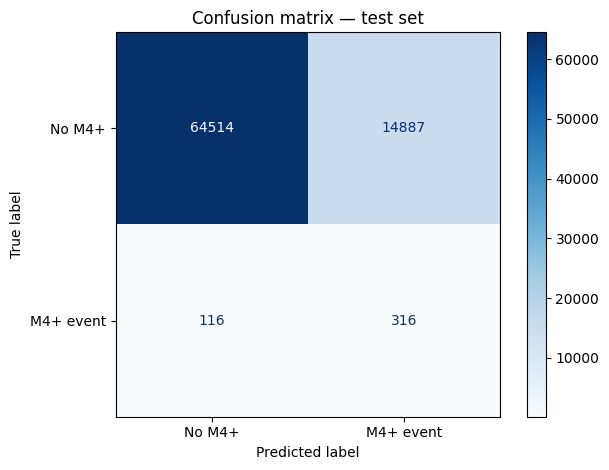

In [15]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             average_precision_score, confusion_matrix,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

print("=== Test Set Metrics ===")
print(f"ROC-AUC:            {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Avg Precision (PR): {average_precision_score(y_test, y_pred_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No M4+', 'M4+ event']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No M4+', 'M4+ event'])
disp.plot(cmap='Blues')
plt.title('Confusion matrix — test set')
plt.tight_layout()
plt.savefig('confusion_matrix_yes.png', dpi=300)
plt.show()

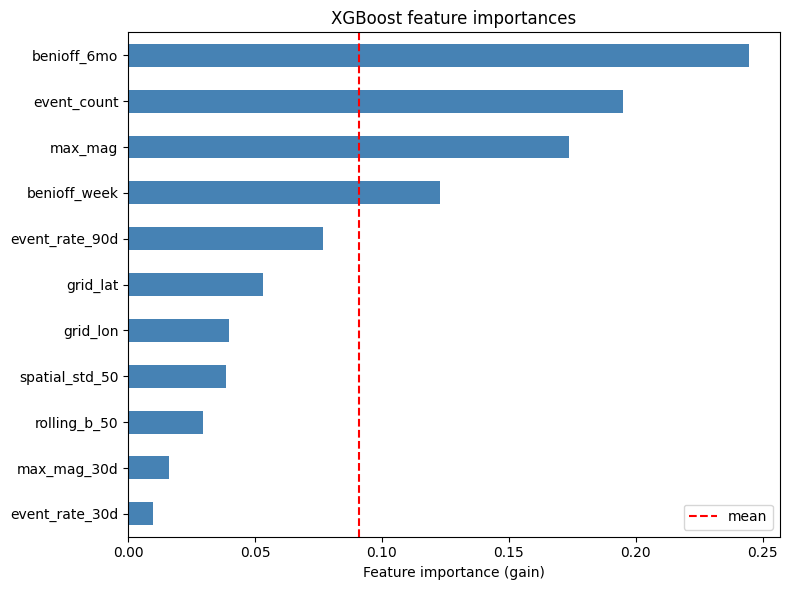


Top 5 features:
benioff_6mo       0.244548
event_count       0.194968
max_mag           0.173661
benioff_week      0.123051
event_rate_90d    0.076875
dtype: float32


In [16]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Feature importance (gain)')
ax.set_title('XGBoost feature importances')
ax.axvline(x=importances.mean(), color='red', linestyle='--', label='mean')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=300)
plt.show()

print("\nTop 5 features:")
print(importances.sort_values(ascending=False).head(5))

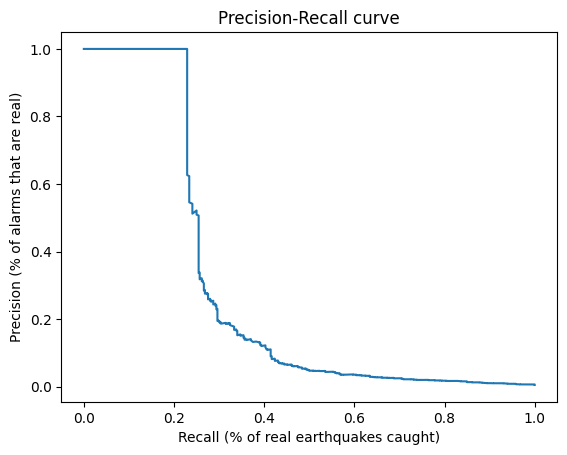

Threshold 0.064 → Precision: 0.005, Recall: 1.000


In [17]:
# Find the threshold that gives you the best precision/recall balance
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot it
import matplotlib.pyplot as plt
plt.plot(recalls, precisions)
plt.xlabel('Recall (% of real earthquakes caught)')
plt.ylabel('Precision (% of alarms that are real)')
plt.title('Precision-Recall curve')
plt.savefig('precision_recall_curve_recnet.png', dpi=300)
plt.show()

# Find threshold where recall >= 0.5 and precision is maximized
for p, r, t in zip(precisions, recalls, thresholds):
    if r >= 0.5:
        print(f"Threshold {t:.3f} → Precision: {p:.3f}, Recall: {r:.3f}")
        break

# After SMOTE Sampling

In [18]:
# Install if needed: !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
# Initialize SMOTE
# sampling_strategy=0.1 means increase earthquakes to 10% of the majority class size
sm = SMOTE(sampling_strategy=0.1, random_state=42)

# Fit and resample only the training data
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_res.shape}")

Original training shape: (513383, 11)
Resampled training shape: (562145, 11)


In [19]:
from xgboost import XGBClassifier

# Remove 'scale_pos_weight' or set it to 1
model_smote = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    # scale_pos_weight=1,  <-- Change this from your previous 'spw'
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42
)

model_smote.fit(X_train_res, y_train_res, eval_set=[(X_val, y_val)])

[0]	validation_0-aucpr:0.28131
[1]	validation_0-aucpr:0.30223
[2]	validation_0-aucpr:0.31552
[3]	validation_0-aucpr:0.32194
[4]	validation_0-aucpr:0.32528
[5]	validation_0-aucpr:0.32326
[6]	validation_0-aucpr:0.32552
[7]	validation_0-aucpr:0.32236
[8]	validation_0-aucpr:0.31433
[9]	validation_0-aucpr:0.31279
[10]	validation_0-aucpr:0.31421
[11]	validation_0-aucpr:0.31250
[12]	validation_0-aucpr:0.31303
[13]	validation_0-aucpr:0.31248
[14]	validation_0-aucpr:0.30975
[15]	validation_0-aucpr:0.31063
[16]	validation_0-aucpr:0.31073
[17]	validation_0-aucpr:0.31098
[18]	validation_0-aucpr:0.31184
[19]	validation_0-aucpr:0.31249
[20]	validation_0-aucpr:0.31118
[21]	validation_0-aucpr:0.31335
[22]	validation_0-aucpr:0.31711
[23]	validation_0-aucpr:0.31747
[24]	validation_0-aucpr:0.31917
[25]	validation_0-aucpr:0.32043
[26]	validation_0-aucpr:0.31900
[27]	validation_0-aucpr:0.31372
[28]	validation_0-aucpr:0.31366
[29]	validation_0-aucpr:0.31497
[30]	validation_0-aucpr:0.31244
[31]	validation_0-

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,30
,enable_categorical,False
,eval_metric,'aucpr'


In [20]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    average_precision_score, f1_score, matthews_corrcoef
)
import numpy as np

# 1. Get raw probabilities and binary predictions
y_probs = model.predict_proba(X_test)[:, 1]
y_final = (model.predict_proba(X_test)[:,1] > 0.92).astype(int)

# 2. Standard Metrics
print("=== CORE METRICS ===")
print(f"ROC-AUC Score:      {roc_auc_score(y_test, y_probs):.4f}")
print(f"Avg Precision (PR): {average_precision_score(y_test, y_probs):.4f}")
print(f"MCC Score:          {matthews_corrcoef(y_test, y_pred):.4f}")

# 3. Detailed Breakdown
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# 4. Confusion Matrix for physical counts
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("\n=== CONFUSION MATRIX (COUNTS) ===")
print(f"True Negatives (No EQ predicted correctly): {tn}")
print(f"False Positives (False Alarms):             {fp}")
print(f"False Negatives (Missed Earthquakes):       {fn}")
print(f"True Positives (Earthquakes caught):        {tp}")

# 5. Finding the Optimal Threshold (Operating Point)
# SMOTE shifts probabilities, so the default 0.5 threshold might not be best.
thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_test, y_probs > t) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

print(f"\nOptimal Threshold (max F1): {best_thresh:.2f}")
print(f"Best possible F1-Score:       {max(f1_scores):.4f}")

=== CORE METRICS ===
ROC-AUC Score:      0.8621
Avg Precision (PR): 0.2896
MCC Score:          0.1016

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      0.81      0.90     79401
           1       0.02      0.73      0.04       432

    accuracy                           0.81     79833
   macro avg       0.51      0.77      0.47     79833
weighted avg       0.99      0.81      0.89     79833


=== CONFUSION MATRIX (COUNTS) ===
True Negatives (No EQ predicted correctly): 64514
False Positives (False Alarms):             14887
False Negatives (Missed Earthquakes):       116
True Positives (Earthquakes caught):        316

Optimal Threshold (max F1): 0.92
Best possible F1-Score:       0.3729


/tmp/ipykernel_4071/4128031244.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')


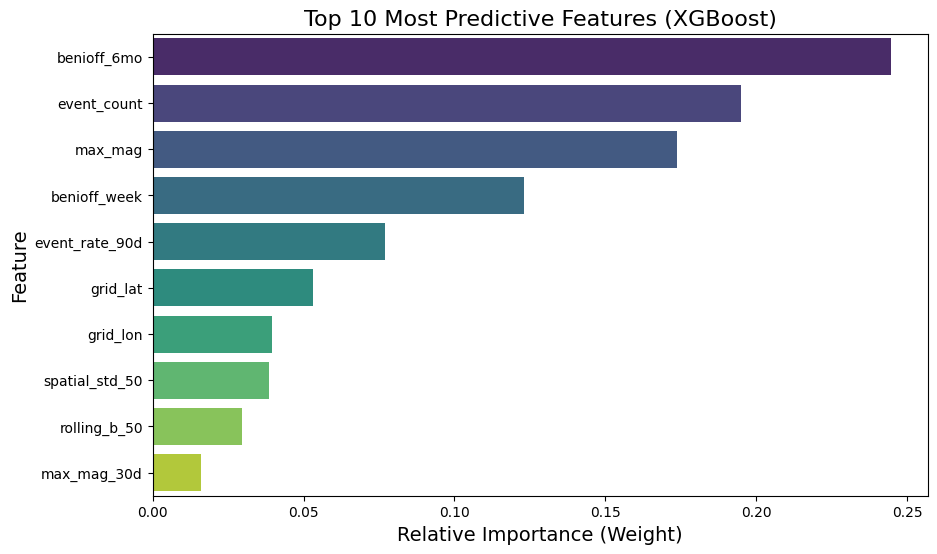

In [24]:
import pandas as pd

# Extract feature importances from XGBoost
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame and sort
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10), palette='viridis')
plt.title('Top 10 Most Predictive Features (XGBoost)', fontsize=16)
plt.xlabel('Relative Importance (Weight)', fontsize=14)
plt.ylabel('Feature', fontsize=14)

plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()